In [4]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.io as pio
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import pickle

def remove_top_right_spines(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.get_xaxis().tick_bottom()            
    ax.get_yaxis().tick_left()
# Apply this to all future plots
plt.rc('axes', facecolor='white')
plt.rc('axes.spines', top=False, right=False)
plt.rc('axes', grid=False)

# Make tick sizes and labels 1.5 times bigger
plt.rc('xtick', labelsize=12)  # Default is 8, so 12 is 1.5x bigger
plt.rc('ytick', labelsize=12)  # Default is 8, so 12 is 1.5x bigger
plt.rc('xtick.major', size=6)  # Default is 4, so 6 is 1.5x bigger
plt.rc('ytick.major', size=6)  # Default is 4, so 6 is 1.5x bigger
plt.rc('xtick.minor', size=3)  # Default is 2, so 3 is 1.5x bigger
plt.rc('ytick.minor', size=3)  # Default is 2, so 3 is 1.5x bigger
plt.rc('xtick.major', width=1.5)  # Default is 1, so 1.5 is 1.5x bigger
plt.rc('ytick.major', width=1.5)  # Default is 1, so 1.5 is 1.5x bigger

# Configure plotly defaults
pio.templates.default = "plotly_white"
pio.templates["plotly_white"].layout.update(
    paper_bgcolor='white',
    plot_bgcolor='white',
    xaxis=dict(
        showline=True,
        linewidth=1,
        linecolor='black',
        mirror=False,
        ticks='outside',
        tickwidth=1,
        tickcolor='black'
    ),
    yaxis=dict(
        showline=True,
        linewidth=1,
        linecolor='black',
        mirror=False,
        ticks='outside',
        tickwidth=1,
        tickcolor='black'
    )
)

import matplotlib.cm as cm
import sys, os, importlib, warnings, pickle
from scipy.stats import pearsonr
from lifelines import KaplanMeierFitter, NelsonAalenFitter
import multiprocessing as mp
mp.set_start_method("fork", force=True)   # must be the first multiprocessing call


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [6]:
allele_table = pd.read_csv('saved_results/allele_table.csv')
allele_table.head()

,SNP,maf,BETA_MAF,SE,Distribution,outlier,Impact
0,1:21575906:C:T,0.000102,-2.027614,0.095571,Quantitative,ALPL - ALK,Likely altering
1,1:21563212:A:C,0.000400,-1.877667,0.069341,Quantitative,ALPL - ALK,NaN
2,1:21573683:A:C,0.000182,-1.806453,0.118118,Quantitative,ALPL - ALK,Likely altering
3,1:21573693:C:A,0.000106,-1.682834,0.157028,Quantitative,NaN,NaN
4,1:21564094:G:A,0.000308,-1.586522,0.061858,Quantitative,NaN,Likely altering


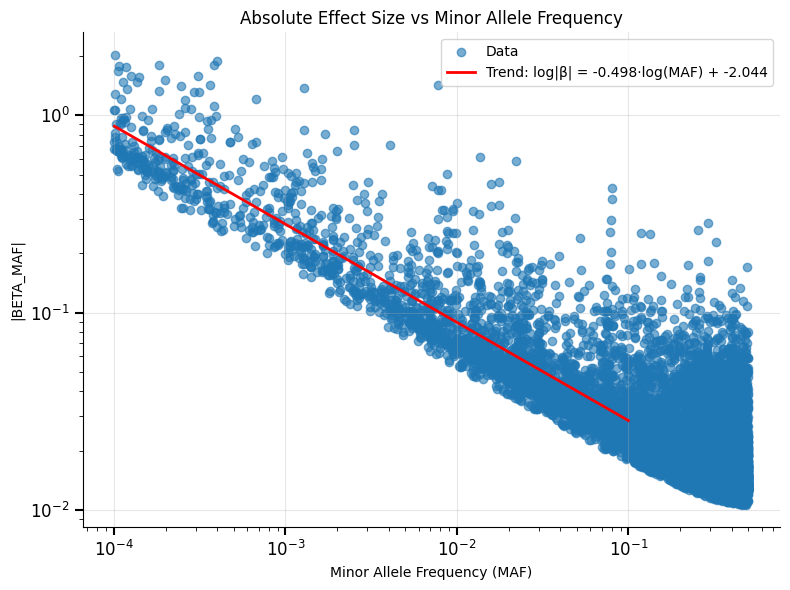

In [8]:
# Filter data for maf < 1e-1
mask = allele_table['maf'] < 1e-1
filtered_data = allele_table[mask]

# Calculate log values
log_maf = np.log10(filtered_data['maf'])
log_abs_beta = np.log10(np.abs(filtered_data['BETA_MAF']))

# Fit linear trend
coeffs = np.polyfit(log_maf, log_abs_beta, 1)
slope, intercept = coeffs[0], coeffs[1]

# Generate trend line
log_maf_range = np.linspace(log_maf.min(), log_maf.max(), 100)
log_abs_beta_trend = slope * log_maf_range + intercept

# Convert back to original scale for plotting
maf_range = 10**log_maf_range
abs_beta_trend = 10**log_abs_beta_trend

plt.figure(figsize=(8, 6))
plt.scatter(allele_table['maf'], np.abs(allele_table['BETA_MAF']), alpha=0.6, label='Data')
plt.plot(maf_range, abs_beta_trend, 'r-', linewidth=2, label=f'Trend: log|β| = {slope:.3f}·log(MAF) + {intercept:.3f}')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Minor Allele Frequency (MAF)')
plt.ylabel('|BETA_MAF|')
plt.title('Absolute Effect Size vs Minor Allele Frequency')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
